# **Berlin Weather EDA: **

*   Climate Patterns
*   Missing Data Quality

*   Seasonal Trends from DWD API Data






1.  How have Berlin temperatures changed over recent years?

2.  Which months show the strongest seasonality in temperature, sunshine, wind, and precipitation?
Are extreme weather days increasing?
Examples: heat days >30°C, frost days <0°C, heavy rain days.
3. How complete is the API weather data?

 Which variables have the most missing values?
Does Berlin rain more often in some seasons, or are rainy days just more intense?
What does a “typical Berlin weather year” look like?
Can we detect anomalies, such as unusual heatwaves, cold spells, or rainfall spikes?




In [57]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from time import sleep
from calendar import monthrange
import os
os.makedirs("visuals", exist_ok=True)



In [52]:
BASE_URL = "https://api.brightsky.dev/weather"

def fetch_weather(lat, lon, start_date, end_date):
    params = {
        "lat": lat,
        "lon": lon,
        "date": start_date,
        "last_date": end_date
    }

    response = requests.get(BASE_URL, params=params, timeout=120)
    response.raise_for_status()

    data = response.json()
    return pd.DataFrame(data["weather"])


def fetch_weather_by_month(lat, lon, start_year, end_year):
    monthly_data = []

    for year in range(start_year, end_year + 1):
        for month in range(1, 13):
            last_day = monthrange(year, month)[1]

            start_date = f"{year}-{month:02d}-01"
            end_date = f"{year}-{month:02d}-{last_day}"

            print(f"Fetching {start_date} to {end_date}...")

            try:
                temp_df = fetch_weather(lat, lon, start_date, end_date)
                temp_df["requested_start_date"] = start_date
                temp_df["requested_end_date"] = end_date
                monthly_data.append(temp_df)

            except requests.exceptions.RequestException as e:
                print(f"Failed for {start_date} to {end_date}: {e}")

            sleep(1)

    return pd.concat(monthly_data, ignore_index=True)


df = fetch_weather_by_month(
    lat=52.52,
    lon=13.405,
    start_year=2020,
    end_year=2025
)

df.head()

Fetching 2020-01-01 to 2020-01-31...
Fetching 2020-02-01 to 2020-02-29...
Fetching 2020-03-01 to 2020-03-31...
Fetching 2020-04-01 to 2020-04-30...
Fetching 2020-05-01 to 2020-05-31...
Fetching 2020-06-01 to 2020-06-30...
Fetching 2020-07-01 to 2020-07-31...
Fetching 2020-08-01 to 2020-08-31...
Fetching 2020-09-01 to 2020-09-30...
Fetching 2020-10-01 to 2020-10-31...
Fetching 2020-11-01 to 2020-11-30...
Fetching 2020-12-01 to 2020-12-31...
Fetching 2021-01-01 to 2021-01-31...
Fetching 2021-02-01 to 2021-02-28...
Fetching 2021-03-01 to 2021-03-31...
Fetching 2021-04-01 to 2021-04-30...
Fetching 2021-05-01 to 2021-05-31...
Fetching 2021-06-01 to 2021-06-30...
Fetching 2021-07-01 to 2021-07-31...
Fetching 2021-08-01 to 2021-08-31...
Fetching 2021-09-01 to 2021-09-30...
Fetching 2021-10-01 to 2021-10-31...
Fetching 2021-11-01 to 2021-11-30...
Fetching 2021-12-01 to 2021-12-31...
Fetching 2022-01-01 to 2022-01-31...
Fetching 2022-02-01 to 2022-02-28...
Fetching 2022-03-01 to 2022-03-31...
F

,timestamp,source_id,precipitation,pressure_msl,sunshine,temperature,wind_direction,wind_speed,cloud_cover,dew_point,...,wind_gust_direction,wind_gust_speed,condition,precipitation_probability,precipitation_probability_6h,solar,fallback_source_ids,icon,requested_start_date,requested_end_date
0,2020-01-01T00:00:00+00:00,206640,0.0,1033.59,NaN,4.4,270,9.4,87.0,1.4,...,260,14.0,dry,None,None,0.0,"{'cloud_cover': 6885, 'visibility': 6885}",cloudy,2020-01-01,2020-01-31
1,2020-01-01T01:00:00+00:00,206640,0.0,1033.30,NaN,3.5,270,11.2,12.0,1.5,...,280,18.0,dry,None,None,0.0,"{'cloud_cover': 6885, 'visibility': 6885}",clear-night,2020-01-01,2020-01-31
2,2020-01-01T02:00:00+00:00,206640,0.0,1033.70,NaN,2.8,280,10.4,12.0,1.4,...,290,19.1,dry,None,None,0.0,"{'cloud_cover': 6885, 'visibility': 6885}",clear-night,2020-01-01,2020-01-31
3,2020-01-01T03:00:00+00:00,206640,0.0,1033.70,0.0,2.4,260,9.0,100.0,1.2,...,280,15.5,dry,None,None,0.0,"{'cloud_cover': 6885, 'visibility': 6885}",cloudy,2020-01-01,2020-01-31
4,2020-01-01T04:00:00+00:00,206640,0.0,1033.90,0.0,3.1,270,9.4,100.0,1.7,...,280,17.3,dry,None,None,0.0,"{'cloud_cover': 6885, 'visibility': 6885}",cloudy,2020-01-01,2020-01-31


## Missing Value Analysis and Cleaning Strategy

In [18]:
df.shape

(50952, 22)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50952 entries, 0 to 50951
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   timestamp                     50952 non-null  object 
 1   source_id                     50952 non-null  int64  
 2   precipitation                 50952 non-null  float64
 3   pressure_msl                  50952 non-null  float64
 4   sunshine                      42782 non-null  float64
 5   temperature                   50952 non-null  float64
 6   wind_direction                50952 non-null  int64  
 7   wind_speed                    50952 non-null  float64
 8   cloud_cover                   50949 non-null  float64
 9   dew_point                     50952 non-null  float64
 10  relative_humidity             50952 non-null  int64  
 11  visibility                    50952 non-null  int64  
 12  wind_gust_direction           50952 non-null  int64  
 13  w

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
source_id,50952.0,262817.674360,50904.472310,206640.0,206640.000,303712.000,312070.000,312070.000
precipitation,50952.0,0.056718,0.386613,0.0,0.000,0.000,0.000,19.400
pressure_msl,50952.0,1015.867063,9.562474,978.7,1010.100,1016.300,1022.000,1047.090
sunshine,42782.0,15.571923,23.350562,0.0,0.000,0.000,32.000,60.000
temperature,50952.0,11.313297,7.927148,-11.9,5.275,10.800,17.100,37.700
wind_direction,50952.0,197.869956,90.524969,0.0,120.000,210.000,270.000,360.000
wind_speed,50952.0,13.476955,6.950078,0.7,8.300,12.600,17.300,55.100
cloud_cover,50949.0,67.077273,35.494498,0.0,37.000,87.000,100.000,100.000
dew_point,50952.0,6.100222,6.164588,-13.6,1.600,6.300,10.800,20.900
relative_humidity,50952.0,73.573520,18.889391,15.0,60.000,78.000,89.000,100.000


In [26]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("missing_count")
)

missing_summary["missing_percent"] = (
    missing_summary["missing_count"] / len(df) * 100
)

missing_summary.sort_values("missing_percent", ascending=False)

,missing_count,missing_percent
precipitation_probability,50952,100.000000
precipitation_probability_6h,50952,100.000000
sunshine,8170,16.034699
cloud_cover,3,0.005888
solar,1,0.001963
timestamp,0,0.000000
temperature,0,0.000000
pressure_msl,0,0.000000
precipitation,0,0.000000
source_id,0,0.000000


In [53]:
GERMAN_BUSINESS_COLORS = {
    "primary": "#1F4E79",      # deep business blue
    "secondary": "#5B9BD5",    # soft blue
    "dark": "#1F2937",         # near-black grey
    "medium": "#6B7280",       # text grey
    "light": "#E5E7EB",        # grid grey
    "background": "#FFFFFF",   # white
    "accent": "#70AD47"        # muted green
}

In [54]:
C = GERMAN_BUSINESS_COLORS

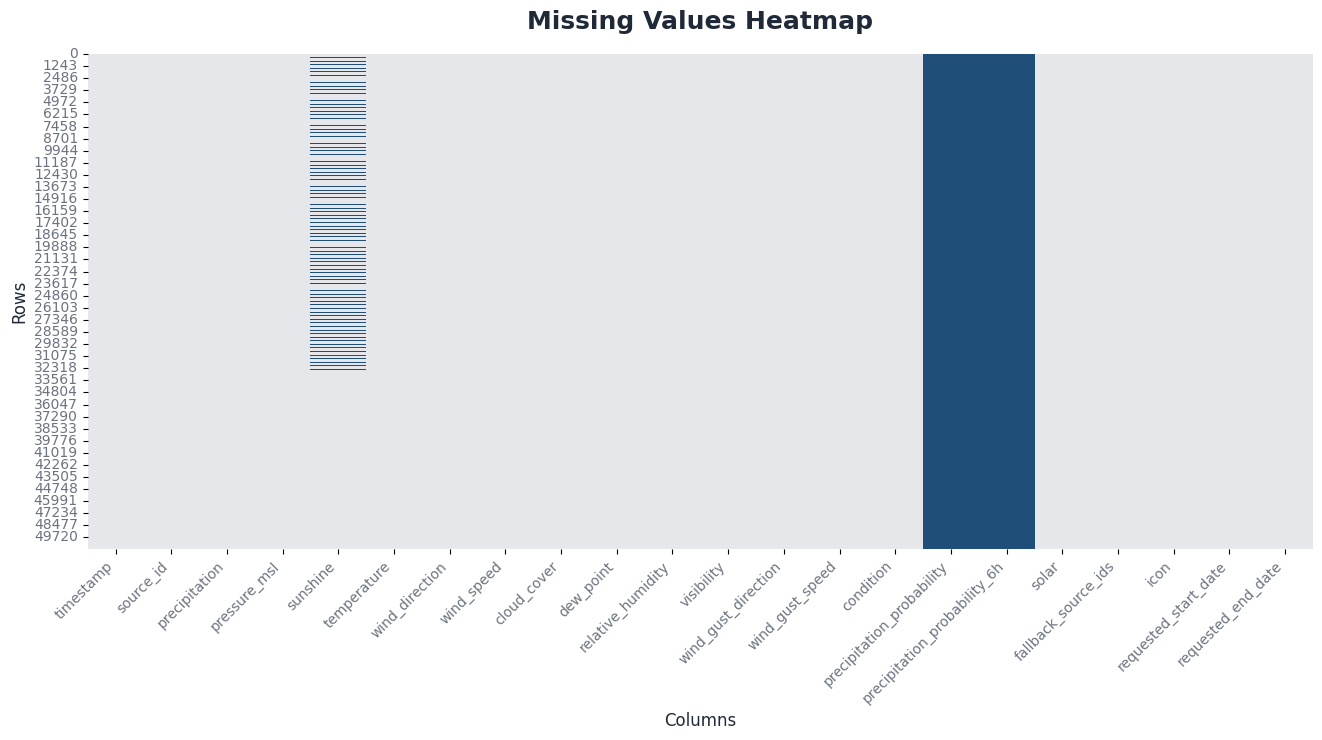

In [61]:
  business_cmap = ListedColormap([
      C["light"],      # 0 = not missing
      C["primary"]     # 1 = missing
  ])

  plt.figure(figsize=(13.33, 7.5))  # 16:9 business/report ratio

  sns.heatmap(
      df.isna(),
      cbar=False,
      cmap=business_cmap
  )

  plt.title(
      "Missing Values Heatmap",
      fontsize=18,
      fontweight="bold",
      color=C["dark"],
      pad=18
  )

  plt.xlabel("Columns", fontsize=12, color=C["dark"])
  plt.ylabel("Rows", fontsize=12, color=C["dark"])

  plt.xticks(rotation=45, ha="right", color=C["medium"])
  plt.yticks(color=C["medium"])

  plt.tight_layout()

  plt.savefig(
      "visuals/missing_values_heatmap.png",
      dpi=300,
      bbox_inches="tight",
      facecolor=C["background"]
  )

  plt.show()

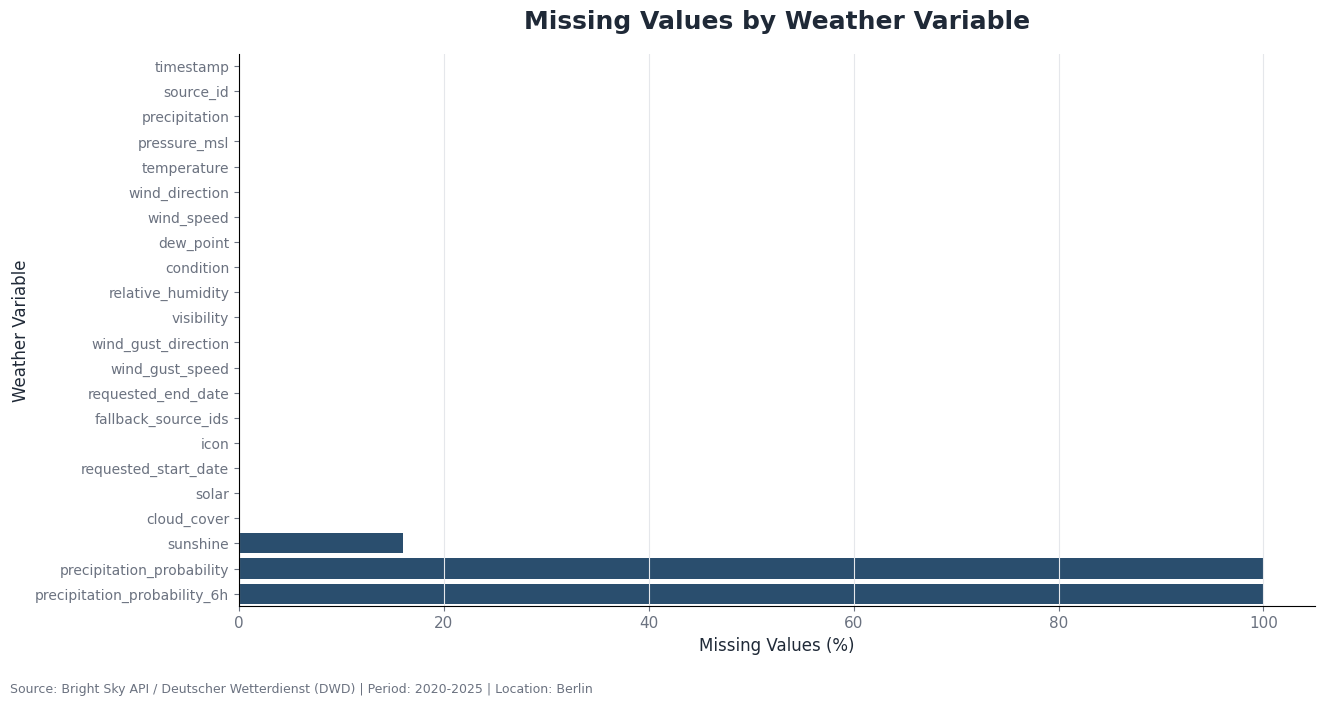

In [63]:
missing_percent = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

plt.figure(figsize=(13.33, 7.5))

ax = sns.barplot(
    x=missing_percent.values,
    y=missing_percent.index,
    color=C["primary"]
)

ax.set_title(
    "Missing Values by Weather Variable",
    fontsize=18,
    fontweight="bold",
    color=C["dark"],
    pad=18
)

ax.set_xlabel("Missing Values (%)", fontsize=12, color=C["dark"])
ax.set_ylabel("Weather Variable", fontsize=12, color=C["dark"])
ax.grid(axis="x", color=C.get("grid", C["light"]), linewidth=0.8)
ax.grid(axis="y", visible=False)

ax.tick_params(axis="x", colors=C["medium"], labelsize=11)
ax.tick_params(axis="y", colors=C["medium"], labelsize=10)

sns.despine()

plt.figtext(
    0.01,
    0.01,
    "Source: Bright Sky API / Deutscher Wetterdienst (DWD) | Period: 2020-2025 | Location: Berlin",
    fontsize=9,
    color=C["medium"]
)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

plt.savefig(
    "visuals/missing_values_by_variable.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=C["background"]
)

plt.show()

In [65]:
missing_percent = (
    df.isna()
    .mean()
    .mul(100)
    .sort_values(ascending=True)
)

missing_percent_nonzero = missing_percent[missing_percent > 0]
print(missing_percent_nonzero)

solar                             0.001963
cloud_cover                       0.005888
sunshine                         16.034699
precipitation_probability       100.000000
precipitation_probability_6h    100.000000
dtype: float64


In [28]:
df.columns

Index(['timestamp', 'source_id', 'precipitation', 'pressure_msl', 'sunshine',
       'temperature', 'wind_direction', 'wind_speed', 'cloud_cover',
       'dew_point', 'relative_humidity', 'visibility', 'wind_gust_direction',
       'wind_gust_speed', 'condition', 'precipitation_probability',
       'precipitation_probability_6h', 'solar', 'fallback_source_ids', 'icon',
       'requested_start_date', 'requested_end_date'],
      dtype='object')

In [29]:
# Choosing columns
important_cols = [
    "timestamp",
    "temperature",
    "precipitation",
    "sunshine",
    "wind_speed",
    "wind_direction",
    "pressure_msl",
    "relative_humidity",
    "cloud_cover"
]

weather = df[important_cols].copy()

In [30]:
weather.head(3)

,timestamp,temperature,precipitation,sunshine,wind_speed,wind_direction,pressure_msl,relative_humidity,cloud_cover
0,2020-01-01T00:00:00+00:00,4.4,0.0,NaN,9.4,270,1033.59,81,87.0
1,2020-01-01T01:00:00+00:00,3.5,0.0,NaN,11.2,270,1033.30,87,12.0
2,2020-01-01T02:00:00+00:00,2.8,0.0,NaN,10.4,280,1033.70,90,12.0


In [32]:
weather["precipitation"] = weather["precipitation"].fillna(0)
weather["sunshine"] = weather["sunshine"].fillna(0)

In [33]:
numeric_cols = [
    "temperature",
    "wind_speed",
    "pressure_msl",
    "relative_humidity",
    "cloud_cover"
]

weather[numeric_cols] = weather[numeric_cols].interpolate(method="linear")

In [34]:
weather.isna().sum()

,0
timestamp,0
temperature,0
precipitation,0
sunshine,0
wind_speed,0
wind_direction,0
pressure_msl,0
relative_humidity,0
cloud_cover,0


In [36]:
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

In [37]:
weather["timestamp"].dtype

datetime64[ns, UTC]

In [38]:
# creating daily dataset
daily_weather = (
    weather
    .set_index("timestamp")
    .resample("D")
    .agg({
        "temperature": "mean",
        "precipitation": "sum",
        "sunshine": "sum",
        "wind_speed": "mean",
        "pressure_msl": "mean",
        "relative_humidity": "mean",
        "cloud_cover": "mean"
    })
    .reset_index()
)

daily_weather.head()

,timestamp,temperature,precipitation,sunshine,wind_speed,pressure_msl,relative_humidity,cloud_cover
0,2020-01-01 00:00:00+00:00,2.733333,0.0,92.0,9.041667,1033.060833,87.750000,48.250000
1,2020-01-02 00:00:00+00:00,0.875000,0.0,374.0,6.162500,1026.810833,76.291667,22.166667
2,2020-01-03 00:00:00+00:00,4.641667,4.3,0.0,15.254167,1017.625000,88.375000,82.666667
3,2020-01-04 00:00:00+00:00,4.150000,5.7,0.0,22.783333,1020.257917,85.416667,60.208333
4,2020-01-05 00:00:00+00:00,1.845833,0.0,99.0,11.316667,1032.548750,84.500000,51.416667


In [39]:
daily_weather["year"] = daily_weather["timestamp"].dt.year
daily_weather["month"] = daily_weather["timestamp"].dt.month
daily_weather["month_name"] = daily_weather["timestamp"].dt.month_name()
daily_weather["day_of_year"] = daily_weather["timestamp"].dt.dayofyear

daily_weather["season"] = daily_weather["month"].map({
    12: "Winter", 1: "Winter", 2: "Winter",
    3: "Spring", 4: "Spring", 5: "Spring",
    6: "Summer", 7: "Summer", 8: "Summer",
    9: "Autumn", 10: "Autumn", 11: "Autumn"
})

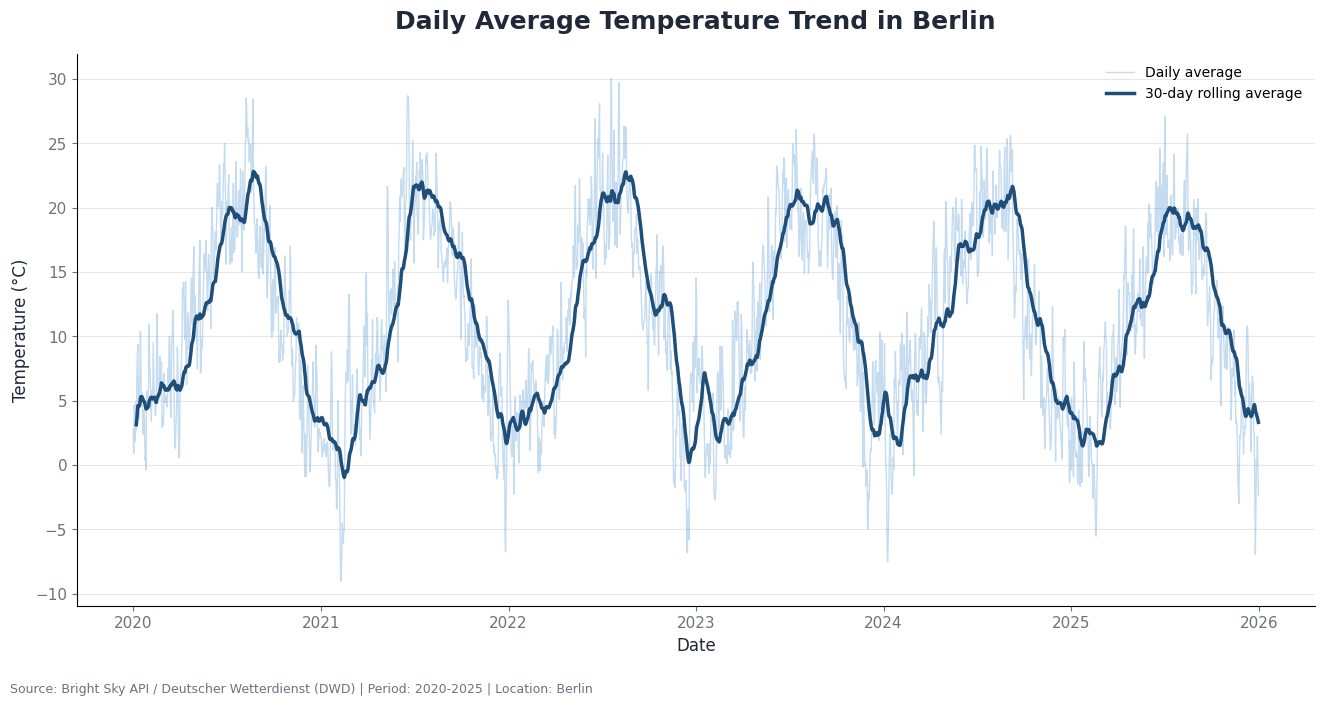

In [66]:
# temperature trend

# Create rolling average for smoother trend
daily_weather["temperature_30d_avg"] = (
    daily_weather["temperature"]
    .rolling(window=30, min_periods=7)
    .mean()
)

plt.figure(figsize=(13.33, 7.5))

ax = plt.gca()

# Daily temperature line
sns.lineplot(
    data=daily_weather,
    x="timestamp",
    y="temperature",
    color=C["secondary"],
    linewidth=1,
    alpha=0.35,
    label="Daily average",
    ax=ax
)

# 30-day rolling average
sns.lineplot(
    data=daily_weather,
    x="timestamp",
    y="temperature_30d_avg",
    color=C["primary"],
    linewidth=2.5,
    label="30-day rolling average",
    ax=ax
)

ax.set_title(
    "Daily Average Temperature Trend in Berlin",
    fontsize=18,
    fontweight="bold",
    color=C["dark"],
    pad=18
)

ax.set_xlabel("Date", fontsize=12, color=C["dark"])
ax.set_ylabel("Temperature (°C)", fontsize=12, color=C["dark"])

ax.grid(axis="y", color=C.get("grid", C["light"]), linewidth=0.8)
ax.grid(axis="x", visible=False)

ax.tick_params(axis="x", colors=C["medium"], labelsize=11)
ax.tick_params(axis="y", colors=C["medium"], labelsize=11)

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

sns.despine()

plt.figtext(
    0.01,
    0.01,
    "Source: Bright Sky API / Deutscher Wetterdienst (DWD) | Period: 2020-2025 | Location: Berlin",
    fontsize=9,
    color=C["medium"]
)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

plt.savefig(
    "visuals/daily_average_temperature_trend_berlin.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=C["background"]
)

plt.show()

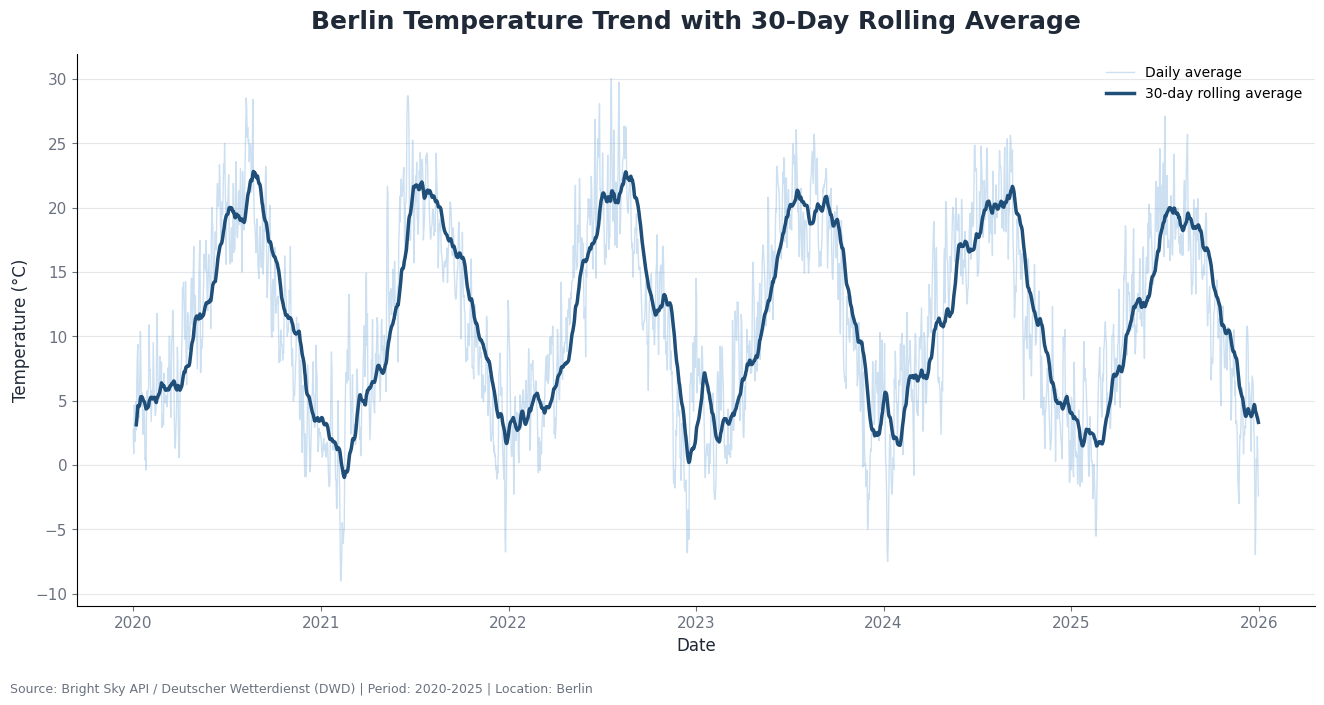

In [67]:
daily_weather["temperature_30d_avg"] = (
    daily_weather["temperature"]
    .rolling(window=30, min_periods=7)
    .mean()
)

C = GERMAN_BUSINESS_COLORS

plt.figure(figsize=(13.33, 7.5))

ax = plt.gca()

plt.plot(
    daily_weather["timestamp"],
    daily_weather["temperature"],
    color=C["secondary"],
    alpha=0.30,
    linewidth=1,
    label="Daily average"
)

plt.plot(
    daily_weather["timestamp"],
    daily_weather["temperature_30d_avg"],
    color=C["primary"],
    linewidth=2.5,
    label="30-day rolling average"
)

ax.set_title(
    "Berlin Temperature Trend with 30-Day Rolling Average",
    fontsize=18,
    fontweight="bold",
    color=C["dark"],
    pad=18
)

ax.set_xlabel("Date", fontsize=12, color=C["dark"])
ax.set_ylabel("Temperature (°C)", fontsize=12, color=C["dark"])

ax.grid(axis="y", color=C.get("grid", C["light"]), linewidth=0.8)
ax.grid(axis="x", visible=False)

ax.tick_params(axis="x", colors=C["medium"], labelsize=11)
ax.tick_params(axis="y", colors=C["medium"], labelsize=11)

ax.legend(
    frameon=False,
    fontsize=10,
    loc="upper right"
)

sns.despine()

plt.figtext(
    0.01,
    0.01,
    "Source: Bright Sky API / Deutscher Wetterdienst (DWD) | Period: 2020-2025 | Location: Berlin",
    fontsize=9,
    color=C["medium"]
)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

plt.savefig(
    "visuals/berlin_temperature_30d_rolling_average.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=C["background"]
)

plt.show()

/tmp/ipykernel_1120/943853674.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(month_labels)


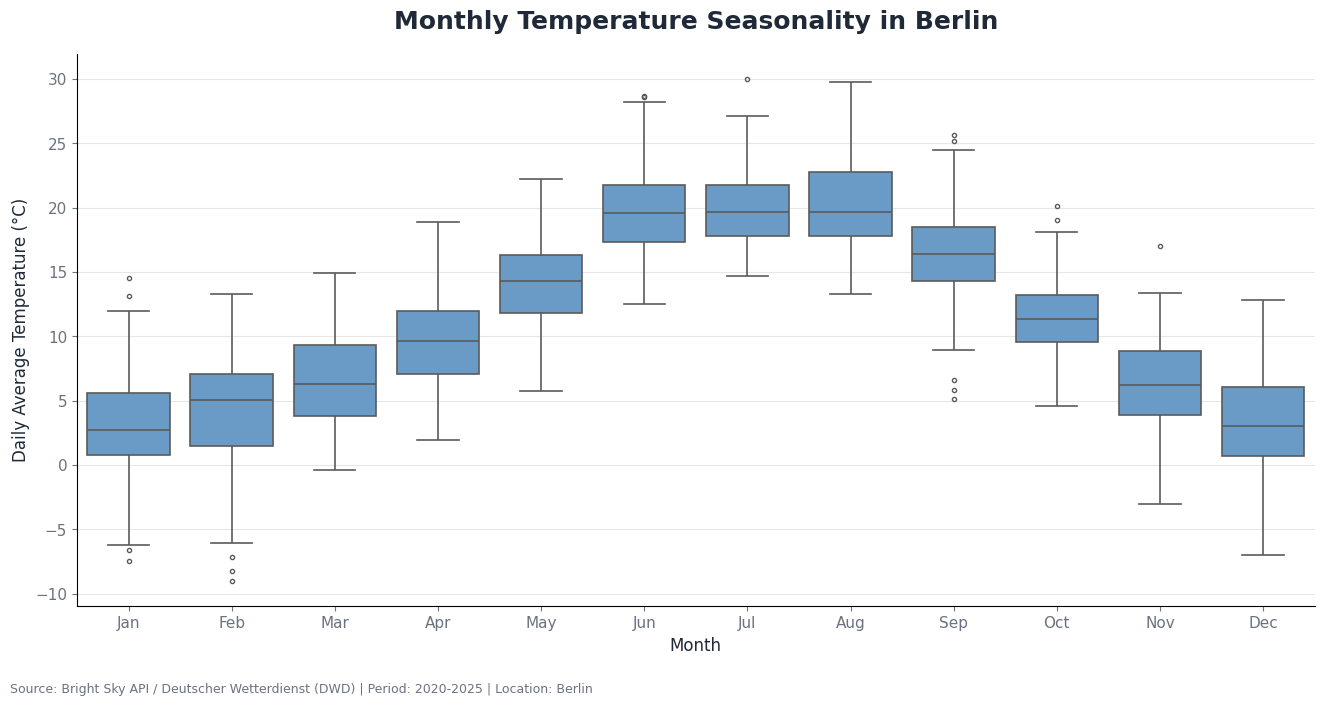

In [68]:


plt.figure(figsize=(13.33, 7.5))

ax = sns.boxplot(
    data=daily_weather,
    x="month",
    y="temperature",
    color=C["secondary"],
    linewidth=1.2,
    fliersize=3
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

ax.set_xticklabels(month_labels)

ax.set_title(
    "Monthly Temperature Seasonality in Berlin",
    fontsize=18,
    fontweight="bold",
    color=C["dark"],
    pad=18
)

ax.set_xlabel("Month", fontsize=12, color=C["dark"])
ax.set_ylabel("Daily Average Temperature (°C)", fontsize=12, color=C["dark"])

ax.grid(axis="y", color=C.get("grid", C["light"]), linewidth=0.8)
ax.grid(axis="x", visible=False)

ax.tick_params(axis="x", colors=C["medium"], labelsize=11)
ax.tick_params(axis="y", colors=C["medium"], labelsize=11)

sns.despine()

plt.figtext(
    0.01,
    0.01,
    "Source: Bright Sky API / Deutscher Wetterdienst (DWD) | Period: 2020-2025 | Location: Berlin",
    fontsize=9,
    color=C["medium"]
)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

plt.savefig(
    "visuals/monthly_temperature_seasonality_berlin.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=C["background"]
)

plt.show()

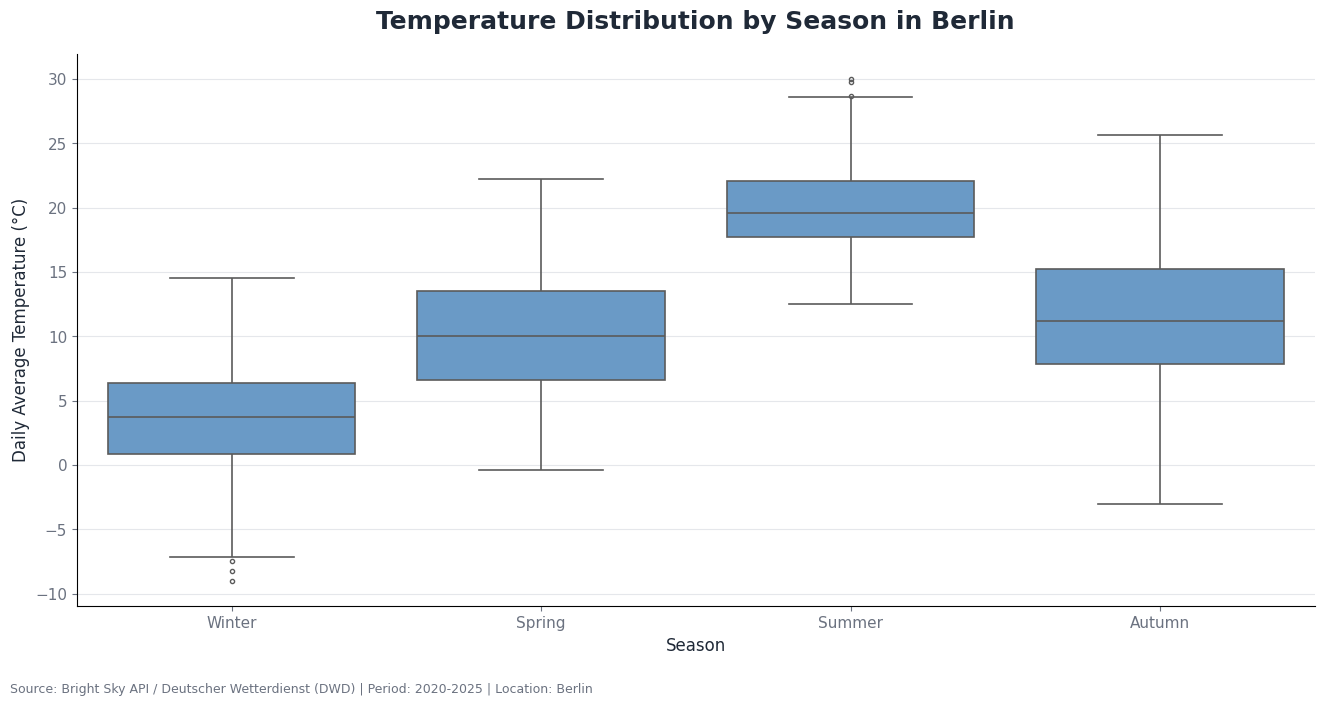

In [69]:

season_order = ["Winter", "Spring", "Summer", "Autumn"]

plt.figure(figsize=(13.33, 7.5))

ax = sns.boxplot(
    data=daily_weather,
    x="season",
    y="temperature",
    order=season_order,
    color=C["secondary"],
    linewidth=1.2,
    fliersize=3
)

ax.set_title(
    "Temperature Distribution by Season in Berlin",
    fontsize=18,
    fontweight="bold",
    color=C["dark"],
    pad=18
)

ax.set_xlabel("Season", fontsize=12, color=C["dark"])
ax.set_ylabel("Daily Average Temperature (°C)", fontsize=12, color=C["dark"])

ax.grid(axis="y", color=C.get("grid", C["light"]), linewidth=0.8)
ax.grid(axis="x", visible=False)

ax.tick_params(axis="x", colors=C["medium"], labelsize=11)
ax.tick_params(axis="y", colors=C["medium"], labelsize=11)

sns.despine()

plt.figtext(
    0.01,
    0.01,
    "Source: Bright Sky API / Deutscher Wetterdienst (DWD) | Period: 2020-2025 | Location: Berlin",
    fontsize=9,
    color=C["medium"]
)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

plt.savefig(
    "visuals/temperature_distribution_by_season_berlin.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=C["background"]
)

plt.show()

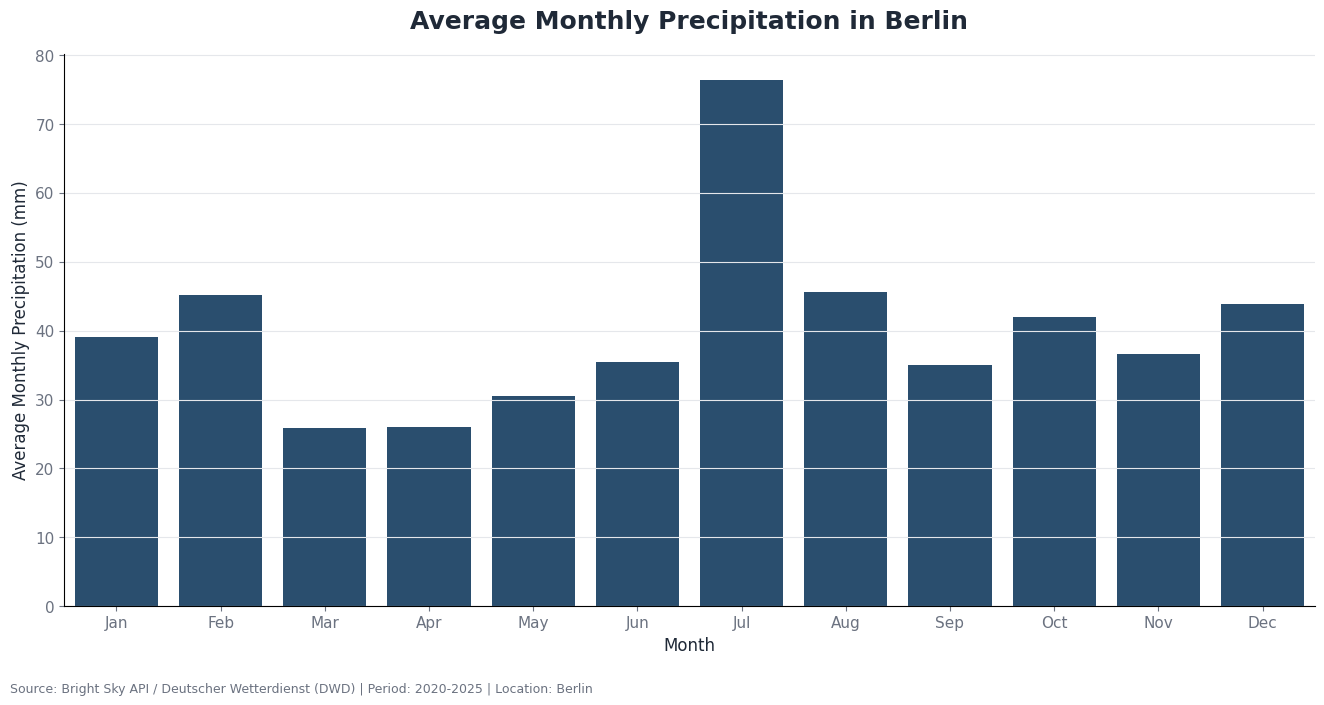

In [71]:


monthly_rain = (
    daily_weather
    .groupby(["year", "month"], as_index=False)["precipitation"]
    .sum()
)

plt.figure(figsize=(13.33, 7.5))

ax = sns.barplot(
    data=monthly_rain,
    x="month",
    y="precipitation",
    estimator="mean",
    color=C["primary"],
    errorbar=None
)

month_labels = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

ax.set_xticks(range(12))
ax.set_xticklabels(month_labels)

ax.set_title(
    "Average Monthly Precipitation in Berlin",
    fontsize=18,
    fontweight="bold",
    color=C["dark"],
    pad=18
)

ax.set_xlabel("Month", fontsize=12, color=C["dark"])
ax.set_ylabel("Average Monthly Precipitation (mm)", fontsize=12, color=C["dark"])

ax.grid(axis="y", color=C.get("grid", C["light"]), linewidth=0.8)
ax.grid(axis="x", visible=False)

ax.tick_params(axis="x", colors=C["medium"], labelsize=11)
ax.tick_params(axis="y", colors=C["medium"], labelsize=11)

sns.despine()

plt.figtext(
    0.01,
    0.01,
    "Source: Bright Sky API / Deutscher Wetterdienst (DWD) | Period: 2020-2025 | Location: Berlin",
    fontsize=9,
    color=C["medium"]
)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

plt.savefig(
    "visuals/average_monthly_precipitation_berlin.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=C["background"]
)

plt.show()

In [72]:
daily_weather["heat_day"] = daily_weather["temperature"] >= 30
daily_weather["frost_day"] = daily_weather["temperature"] <= 0
daily_weather["rainy_day"] = daily_weather["precipitation"] > 0
daily_weather["heavy_rain_day"] = daily_weather["precipitation"] >= 10

In [73]:
extreme_days = (
    daily_weather
    .groupby("year", as_index=False)
    .agg({
        "heat_day": "sum",
        "frost_day": "sum",
        "rainy_day": "sum",
        "heavy_rain_day": "sum"
    })
)

extreme_days

,year,heat_day,frost_day,rainy_day,heavy_rain_day
0,2020,0,6,144,16
1,2021,0,30,177,9
2,2022,1,20,144,6
3,2023,0,18,171,22
4,2024,0,16,138,7
5,2025,0,26,128,8


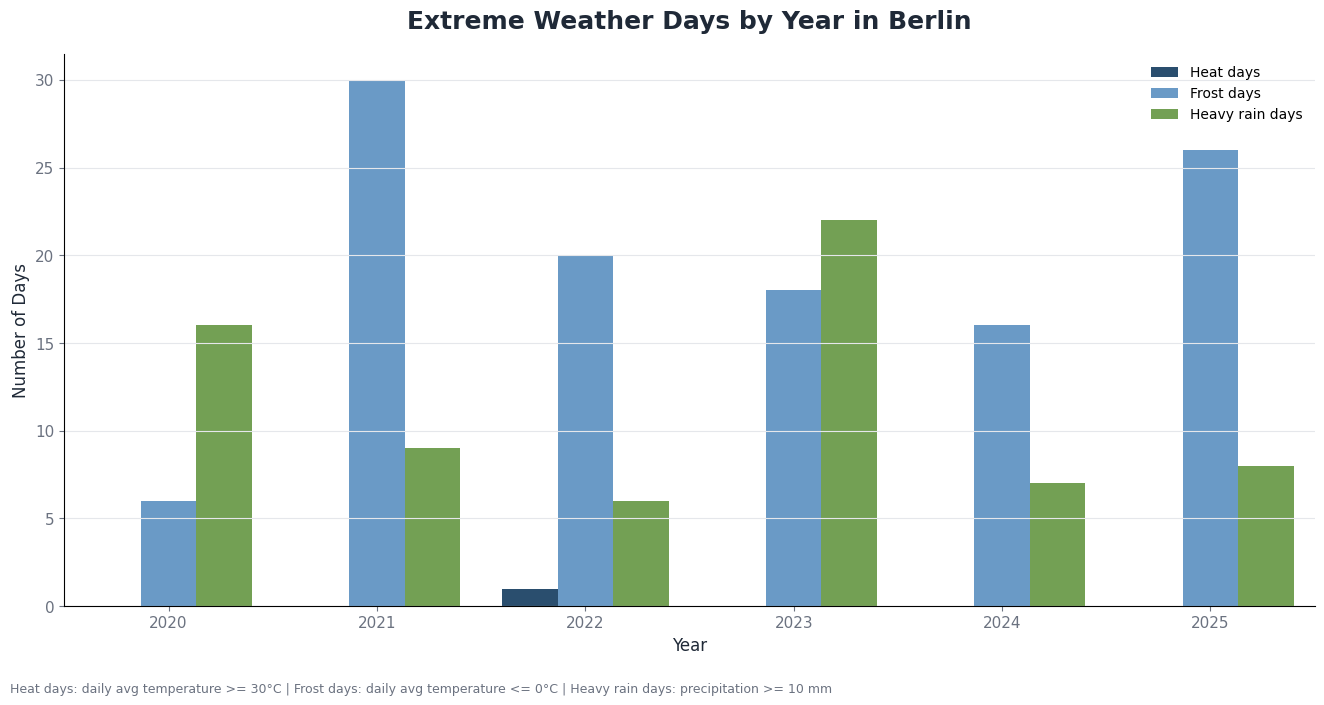

In [74]:


extreme_days_melted = extreme_days.melt(
    id_vars="year",
    value_vars=["heat_day", "frost_day", "heavy_rain_day"],
    var_name="day_type",
    value_name="number_of_days"
)

day_type_labels = {
    "heat_day": "Heat days",
    "frost_day": "Frost days",
    "heavy_rain_day": "Heavy rain days"
}

extreme_days_melted["day_type"] = extreme_days_melted["day_type"].map(day_type_labels)

plt.figure(figsize=(13.33, 7.5))

ax = sns.barplot(
    data=extreme_days_melted,
    x="year",
    y="number_of_days",
    hue="day_type",
    palette=[C["primary"], C["secondary"], C["accent"]]
)

ax.set_title(
    "Extreme Weather Days by Year in Berlin",
    fontsize=18,
    fontweight="bold",
    color=C["dark"],
    pad=18
)

ax.set_xlabel("Year", fontsize=12, color=C["dark"])
ax.set_ylabel("Number of Days", fontsize=12, color=C["dark"])

ax.grid(axis="y", color=C.get("grid", C["light"]), linewidth=0.8)
ax.grid(axis="x", visible=False)

ax.tick_params(axis="x", colors=C["medium"], labelsize=11)
ax.tick_params(axis="y", colors=C["medium"], labelsize=11)

ax.legend(
    title=None,
    frameon=False,
    fontsize=10,
    loc="upper right"
)

sns.despine()

plt.figtext(
    0.01,
    0.01,
    "Heat days: daily avg temperature >= 30°C | Frost days: daily avg temperature <= 0°C | Heavy rain days: precipitation >= 10 mm",
    fontsize=9,
    color=C["medium"]
)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

plt.savefig(
    "visuals/extreme_weather_days_by_year_berlin.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=C["background"]
)

plt.show()

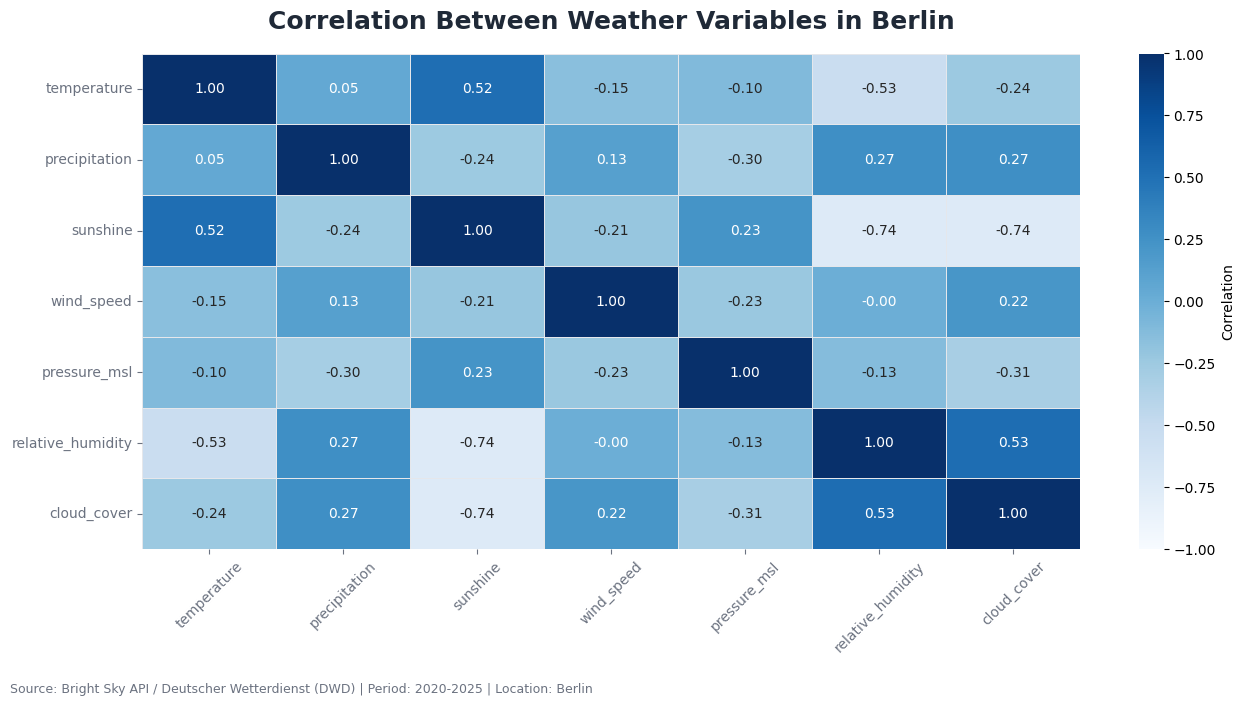

In [75]:


corr_cols = [
    "temperature",
    "precipitation",
    "sunshine",
    "wind_speed",
    "pressure_msl",
    "relative_humidity",
    "cloud_cover"
]

correlation_matrix = daily_weather[corr_cols].corr()

plt.figure(figsize=(13.33, 7.5))

ax = sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor=C.get("grid", C["light"]),
    cbar_kws={"label": "Correlation"}
)

ax.set_title(
    "Correlation Between Weather Variables in Berlin",
    fontsize=18,
    fontweight="bold",
    color=C["dark"],
    pad=18
)

ax.tick_params(axis="x", colors=C["medium"], labelsize=10, rotation=45)
ax.tick_params(axis="y", colors=C["medium"], labelsize=10, rotation=0)

plt.figtext(
    0.01,
    0.01,
    "Source: Bright Sky API / Deutscher Wetterdienst (DWD) | Period: 2020-2025 | Location: Berlin",
    fontsize=9,
    color=C["medium"]
)

plt.tight_layout(rect=[0, 0.04, 1, 0.94])

plt.savefig(
    "visuals/weather_variable_correlation_berlin.png",
    dpi=300,
    bbox_inches="tight",
    facecolor=C["background"]
)

plt.show()

## Key Findings

- Berlin shows a strong seasonal temperature pattern, with highest average temperatures in summer and lowest in winter.
- Rainfall is more irregular than temperature and appears driven by individual high-precipitation days.
- Temperature has a visible annual cycle, while precipitation is less seasonally smooth.
- Missing values were handled differently depending on the variable type.
- Aggregating hourly data into daily values made trends easier to interpret.